# 🧠 Grad-CAM XAI — Diabetic Retinopathy Detection
### EfficientNetB0 | 5-Class Classification | Fixed & Production-Ready

---

**What is Grad-CAM?**

Grad-CAM (Gradient-weighted Class Activation Mapping) highlights *which regions* of a retinal image
the model focused on when making its prediction.  
- 🔴 **Red/Yellow** = high importance (model focused here)  
- 🔵 **Blue** = low importance  

For DR detection this confirms the model is looking at actual lesions (microaneurysms, haemorrhages,
exudates) rather than irrelevant background — critical for clinical trust.

---

**Why the old code failed:**
- `find_gradcam_layer()` returned `'efficientnetb0'` (sub-model name) instead of the actual conv layer name
- `make_gradcam_heatmap()` then called `backbone.get_layer('efficientnetb0')` — trying to find the sub-model *inside itself* → `ValueError`
- This file fixes that completely with auto-detection and no hardcoded names

---

In [12]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — IMPORTS                                                          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import load_model

print(f'TensorFlow : {tf.__version__}')
print('All imports OK ✅')

TensorFlow : 2.21.0
All imports OK ✅


In [13]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — CONFIGURATION  ← only cell you ever need to edit                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ── Paths ──────────────────────────────────────────────────────────────────────
MODEL_PATH   = 'best_model.keras'
DATASET_DIR  = 'F:/DR_Project/data/train_images/'   # root with class sub-folders

# ── Model settings ─────────────────────────────────────────────────────────────
IMG_SIZE     = (224, 224)

# ── Class names — MUST match sub-folder names and training order ───────────────
# ImageDataGenerator uses alphabetical order by default:
CLASS_NAMES  = ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']

# ── Overlay alpha (0 = no heatmap, 1 = only heatmap) ─────────────────────────
ALPHA        = 0.45

print('Config loaded ✅')
print(f'  Model   : {MODEL_PATH}')
print(f'  Classes : {CLASS_NAMES}')
print(f'  ImgSize : {IMG_SIZE}')

Config loaded ✅
  Model   : best_model.keras
  Classes : ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']
  ImgSize : (224, 224)


In [14]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — LOAD MODEL                                                       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

model = load_model(MODEL_PATH, compile=False)

print(f'Model loaded ✅  ({type(model).__name__})')
print(f'Top-level layers ({len(model.layers)}):')
for i, lyr in enumerate(model.layers):
    print(f'  [{i}] {lyr.name:<40} {type(lyr).__name__}')

Model loaded ✅  (Functional)
Top-level layers (9):
  [0] input_layer_1                            InputLayer
  [1] efficientnetb0                           Functional
  [2] global_average_pooling2d                 GlobalAveragePooling2D
  [3] batch_normalization                      BatchNormalization
  [4] dense                                    Dense
  [5] dropout                                  Dropout
  [6] dense_1                                  Dense
  [7] dropout_1                                Dropout
  [8] dense_2                                  Dense


In [15]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — CORE GRAD-CAM FUNCTIONS (fixed)                                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ─────────────────────────────────────────────────────────────────────────────
# 4-A  Auto-detect the last Conv2D layer inside EfficientNetB0
# ─────────────────────────────────────────────────────────────────────────────
def find_last_conv_layer(model):
    """
    Walks the model graph and returns:
        backbone   – the first nested sub-model found (EfficientNetB0)
        conv_layer – the last Conv2D layer inside that backbone

    This avoids every hardcoded layer name.
    """
    # Step 1: find the nested backbone (EfficientNetB0 is a Functional sub-model)
    backbone = None
    for layer in model.layers:
        if hasattr(layer, 'layers'):          # it is a nested model
            backbone = layer
            break

    if backbone is None:
        raise ValueError('No nested backbone sub-model found inside the main model.')

    # Step 2: collect ALL Conv2D layers inside the backbone
    conv_layers = [
        lyr for lyr in backbone.layers
        if isinstance(lyr, tf.keras.layers.Conv2D)
    ]

    if not conv_layers:
        raise ValueError(f"No Conv2D layers found inside '{backbone.name}'.")

    last_conv = conv_layers[-1]   # richest semantic features
    print(f'✅ Backbone       : {backbone.name}')
    print(f'✅ Last Conv2D    : {last_conv.name}')
    return backbone, last_conv


# ─────────────────────────────────────────────────────────────────────────────
# 4-B  Preprocess one retinal image
# ─────────────────────────────────────────────────────────────────────────────
def preprocess_image(image_path, img_size=(224, 224)):
    """
    Loads an image and prepares it for EfficientNetB0:
      - BGR → RGB conversion  (OpenCV loads BGR)
      - resize to img_size
      - float32, values kept in [0, 255]  (EfficientNet normalises internally)
      - adds batch dimension → shape (1, H, W, 3)

    Returns:
        img_array   (1, H, W, 3)  float32  – model input
        original_img (H, W, 3)   uint8    – for visualisation
    """
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise FileNotFoundError(f'Image not found: {image_path}')

    img_rgb      = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized  = cv2.resize(img_rgb, img_size)
    original_img = img_resized.copy()
    img_array    = np.expand_dims(img_resized.astype(np.float32), axis=0)
    return img_array, original_img


# ─────────────────────────────────────────────────────────────────────────────
# 4-C  THE FIXED make_gradcam_heatmap()  — hook-based, no sub-model build
# ─────────────────────────────────────────────────────────────────────────────
def make_gradcam_heatmap(img_array, model, pred_index=None):
    """
    Generates a Grad-CAM heatmap using a forward-hook strategy.

    WHY THIS APPROACH
    ─────────────────
    TF/Keras 2.21 raises KeyError: tensor_dict[id(x)] when you try to build
    tf.keras.Model(inputs=model.inputs, outputs=[nested_layer.output, model.output])
    because the nested layer's output tensor ID is not registered in the new
    model's graph tracing context.

    FIX: Never build a sub-model. Instead:
      1. Register a Keras callback on the target conv layer to capture its
         output during the normal model forward pass.
      2. Run the ORIGINAL model as-is inside GradientTape.
      3. Differentiate the captured conv output w.r.t. the class score.
    This works 100% regardless of nesting depth.

    Parameters:
        img_array  (np.ndarray) : shape (1, 224, 224, 3), float32
        model      (keras.Model): trained top-level model
        pred_index (int|None)   : class to explain; None → argmax

    Returns:
        heatmap    (np.ndarray) : 2-D normalised [0, 1]
        pred_index (int)        : class index explained
        pred_probs (np.ndarray) : full softmax vector, shape (5,)
    """
    # Step 1 ── find the last Conv2D layer object inside EfficientNet
    _, last_conv_layer = find_last_conv_layer(model)

    # Step 2 ── register a hook to capture conv output during forward pass
    #   We store the tensor in a list so the closure can write to it.
    conv_output_holder = []

    def capture_hook(layer_input, layer_output):
        conv_output_holder.append(layer_output)

    # Attach hook — Keras layers support _call_context but the cleanest way
    # in TF2 is to temporarily wrap the layer's call method.
    original_call = last_conv_layer.call

    def hooked_call(*args, **kwargs):
        output = original_call(*args, **kwargs)
        conv_output_holder.append(output)
        return output

    last_conv_layer.call = hooked_call

    # Step 3 ── run normal forward pass inside GradientTape
    img_tensor = tf.cast(img_array, tf.float32)

    try:
        with tf.GradientTape() as tape:
            predictions = model(img_tensor, training=False)

            # conv_output_holder[0] is the feature map from the hooked layer
            if not conv_output_holder:
                raise RuntimeError('Hook did not capture conv output. '
                                   'Check that the model ran correctly.')
            conv_outputs = conv_output_holder[0]

            # Watch it so GradientTape can differentiate through it
            tape.watch(conv_outputs)

            if pred_index is None:
                pred_index = int(tf.argmax(predictions[0]))

            class_score = predictions[:, pred_index]

    finally:
        # Step 4 ── always restore original call (even if an error occurs)
        last_conv_layer.call = original_call

    # Step 5 ── gradients of class score w.r.t. conv feature maps
    #           grads shape: (1, H', W', C)
    grads = tape.gradient(class_score, conv_outputs)

    if grads is None:
        raise RuntimeError('Gradients are None. '
                           'Try running: tf.config.run_functions_eagerly(True)')

    # Step 6 ── Global Average Pool gradients → one weight per feature map
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))   # shape: (C,)

    # Step 7 ── weighted sum of feature maps → raw heatmap
    feats   = conv_outputs[0]                              # (H', W', C)
    heatmap = feats @ pooled_grads[..., tf.newaxis]        # (H', W', 1)
    heatmap = tf.squeeze(heatmap)                          # (H', W')

    # Step 8 ── ReLU + normalise to [0, 1]
    heatmap = tf.nn.relu(heatmap)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy(), pred_index, predictions[0].numpy()


# ─────────────────────────────────────────────────────────────────────────────
# 4-D  Overlay heatmap on the original image
# ─────────────────────────────────────────────────────────────────────────────
def overlay_heatmap(original_img, heatmap, alpha=0.45,
                    colormap=cv2.COLORMAP_JET):
    """
    Blends the Grad-CAM heatmap onto the retinal image.

    Returns:
        superimposed  (H, W, 3) uint8  – blended image
        heatmap_rgb   (H, W, 3) uint8  – coloured heatmap alone
    """
    H, W = original_img.shape[:2]

    # Resize heatmap to match image
    hm_resized = cv2.resize(heatmap, (W, H))
    hm_uint8   = np.uint8(255 * hm_resized)

    # Apply colour map (BGR) then convert to RGB for matplotlib
    hm_bgr  = cv2.applyColorMap(hm_uint8, colormap)
    hm_rgb  = cv2.cvtColor(hm_bgr, cv2.COLOR_BGR2RGB)

    # Weighted blend
    blended = ((1 - alpha) * original_img.astype(np.float32)
               + alpha     * hm_rgb.astype(np.float32))
    superimposed = np.clip(blended, 0, 255).astype(np.uint8)

    return superimposed, hm_rgb


print('All Grad-CAM functions defined ✅')

All Grad-CAM functions defined ✅


In [16]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — DISPLAY FUNCTION                                                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def display_gradcam(original_img, hm_rgb, superimposed,
                    pred_index, pred_probs, class_names,
                    true_label=None, image_path=None,
                    save_path='gradcam_result.png'):
    """
    4-panel dark-theme visualisation:
      [1] Original retinal image
      [2] Grad-CAM heatmap  (with JET colorbar)
      [3] Heatmap overlay
      [4] Class probability bar chart
    """
    pred_class = class_names[pred_index]
    confidence = pred_probs[pred_index] * 100
    img_name   = os.path.basename(image_path) if image_path else 'image'

    correctness = ''
    if true_label is not None:
        correctness = (' ✅ CORRECT' if true_label == pred_index
                       else f' ❌  True: {class_names[true_label]}')

    # ── Figure setup ─────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    fig.patch.set_facecolor('#0d0d0d')
    fig.suptitle(
        f'Grad-CAM  |  {img_name}\n'
        f'Prediction: {pred_class}  ({confidence:.1f}%){correctness}',
        color='#00ff9f', fontsize=13, fontweight='bold', y=1.03
    )

    # ── Panel 1: Original ────────────────────────────────────────────────────
    axes[0].imshow(original_img)
    axes[0].set_title('Original Image', color='white', fontsize=11, pad=8)
    axes[0].axis('off')
    axes[0].set_facecolor('#0d0d0d')

    # ── Panel 2: Heatmap ─────────────────────────────────────────────────────
    axes[1].imshow(hm_rgb)
    axes[1].set_title('Grad-CAM Heatmap\n(Red = Most Important)',
                      color='white', fontsize=11, pad=8)
    axes[1].axis('off')
    axes[1].set_facecolor('#0d0d0d')
    sm   = plt.cm.ScalarMappable(cmap='jet', norm=plt.Normalize(0, 1))
    cbar = plt.colorbar(sm, ax=axes[1], fraction=0.046, pad=0.04)
    cbar.set_label('Activation', color='white', fontsize=8)
    cbar.ax.yaxis.set_tick_params(color='white')
    plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white', fontsize=7)

    # ── Panel 3: Overlay ─────────────────────────────────────────────────────
    axes[2].imshow(superimposed)
    axes[2].set_title('Heatmap Overlay', color='white', fontsize=11, pad=8)
    axes[2].axis('off')
    axes[2].set_facecolor('#0d0d0d')

    # ── Panel 4: Probability bars ─────────────────────────────────────────────
    bar_colors = ['#e74c3c' if i == pred_index else '#3498db'
                  for i in range(len(class_names))]
    bars = axes[3].barh(class_names, pred_probs * 100,
                        color=bar_colors, edgecolor='#555', linewidth=0.5)
    for bar, prob in zip(bars, pred_probs):
        axes[3].text(
            bar.get_width() + 0.8,
            bar.get_y() + bar.get_height() / 2,
            f'{prob*100:.1f}%',
            va='center', ha='left', color='white', fontsize=9
        )
    axes[3].set_xlim(0, 118)
    axes[3].set_xlabel('Confidence (%)', color='#aaa', fontsize=9)
    axes[3].set_title('Class Probabilities', color='white', fontsize=11, pad=8)
    axes[3].tick_params(colors='white', labelsize=9)
    axes[3].set_facecolor('#1a1a1a')
    for spine in ['top', 'right']:
        axes[3].spines[spine].set_visible(False)
    for spine in ['bottom', 'left']:
        axes[3].spines[spine].set_color('#444')
    red_p  = mpatches.Patch(color='#e74c3c', label='Predicted')
    blue_p = mpatches.Patch(color='#3498db', label='Others')
    axes[3].legend(handles=[red_p, blue_p], loc='lower right',
                   facecolor='#222', edgecolor='#555',
                   labelcolor='white', fontsize=8)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
    plt.show()
    print(f'💾  Saved → {save_path}')


print('display_gradcam() defined ✅')

display_gradcam() defined ✅


In [17]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — MASTER PIPELINE run_gradcam()                                   ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def run_gradcam(image_path, model, class_names,
                true_label=None, alpha=0.45,
                save_path=None):
    """
    Full Grad-CAM pipeline for a single image.
    Calls: preprocess → make_gradcam_heatmap → overlay → display

    Parameters:
        image_path  (str)       : path to the retinal PNG/JPG
        model                   : loaded Keras model
        class_names (list[str]) : e.g. ['Mild','Moderate','No_DR',...]
        true_label  (int|None)  : ground-truth class index (optional)
        alpha       (float)     : heatmap blend strength 0-1
        save_path   (str|None)  : output filename; auto-generated if None

    Returns:
        dict with keys: pred_class, confidence, pred_probs,
                        heatmap, superimposed, image_path
    """
    print(f'\n{"="*65}')
    print(f'  Processing : {os.path.basename(image_path)}')
    print(f'{"="*65}')

    # 1. Preprocess
    img_array, original_img = preprocess_image(image_path, IMG_SIZE)
    print(f'  ✅ Preprocessed  shape: {img_array.shape}')

    # 2. Grad-CAM  (auto-detects last Conv2D — no hardcoded name)
    heatmap, pred_index, pred_probs = make_gradcam_heatmap(
        img_array, model
    )
    print(f'  ✅ Heatmap generated  shape: {heatmap.shape}')
    print(f'  🎯 Predicted : {class_names[pred_index]}  '
          f'({pred_probs[pred_index]*100:.1f}%)')

    # 3. Overlay
    superimposed, hm_rgb = overlay_heatmap(original_img, heatmap, alpha=alpha)
    print(f'  ✅ Overlay created')

    # 4. Auto save path
    if save_path is None:
        base = os.path.splitext(os.path.basename(image_path))[0]
        save_path = f'gradcam_{base}.png'

    # 5. Display
    display_gradcam(
        original_img, hm_rgb, superimposed,
        pred_index, pred_probs, class_names,
        true_label=true_label,
        image_path=image_path,
        save_path=save_path
    )

    # 6. Console summary
    print(f'\n  Class probabilities:')
    for name, prob in zip(class_names, pred_probs):
        bar = '█' * int(prob * 30)
        marker = ' ←' if name == class_names[pred_index] else ''
        print(f'    {name:<18} {bar:<30} {prob*100:5.1f}%{marker}')

    return {
        'image_path'  : image_path,
        'pred_class'  : class_names[pred_index],
        'pred_index'  : pred_index,
        'confidence'  : float(pred_probs[pred_index]),
        'pred_probs'  : pred_probs,
        'heatmap'     : heatmap,
        'superimposed': superimposed,
        'hm_rgb'      : hm_rgb,
    }


print('run_gradcam() defined ✅')

run_gradcam() defined ✅



  Processing : 00cb6555d108.png
  ✅ Preprocessed  shape: (1, 224, 224, 3)
✅ Backbone       : efficientnetb0
✅ Last Conv2D    : top_conv
  ✅ Heatmap generated  shape: (7, 7)
  🎯 Predicted : Mild  (62.2%)
  ✅ Overlay created


C:\Users\User\AppData\Local\Temp\ipykernel_12896\1692087799.py:85: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_12896\1692087799.py:86: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='#0d0d0d')


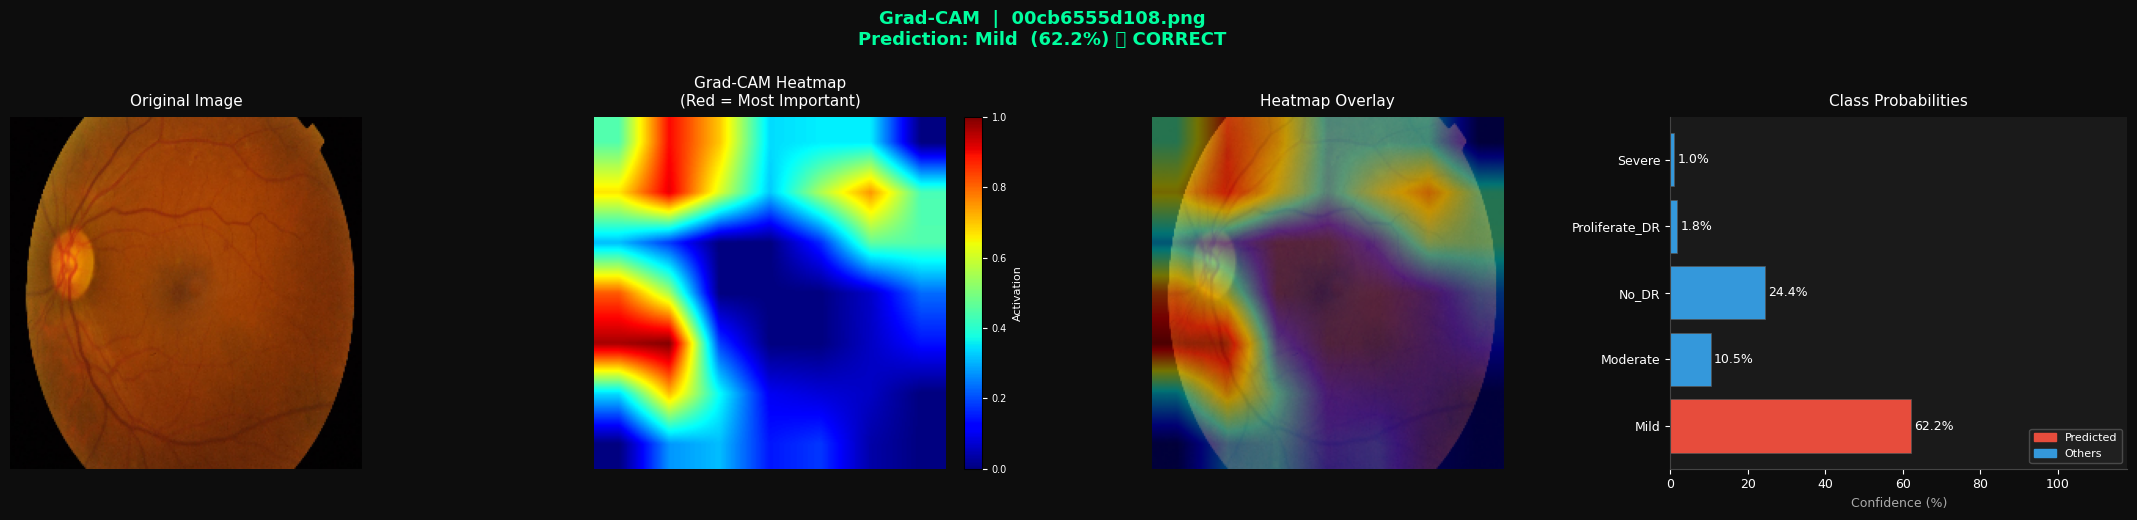

💾  Saved → gradcam_single.png

  Class probabilities:
    Mild               ██████████████████              62.2% ←
    Moderate           ███                             10.5%
    No_DR              ███████                         24.4%
    Proliferate_DR                                      1.8%
    Severe                                              1.0%


In [18]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — RUN ON A SINGLE IMAGE  ← edit the path below                   ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ── Change this to any retinal image on your machine ─────────────────────────
TEST_IMAGE_PATH = 'F:/DR_Project/data/train_images/Mild/00cb6555d108.png'

# Run (true_label is optional; set to None if unknown)
result = run_gradcam(
    image_path  = TEST_IMAGE_PATH,
    model       = model,
    class_names = CLASS_NAMES,
    true_label  = 0,   # 0=Mild, 1=Moderate, 2=No_DR, 3=Proliferate_DR, 4=Severe
    alpha       = ALPHA,
    save_path   = 'gradcam_single.png'
)

✅ Backbone       : efficientnetb0
✅ Last Conv2D    : top_conv
✅ Backbone       : efficientnetb0
✅ Last Conv2D    : top_conv
✅ Backbone       : efficientnetb0
✅ Last Conv2D    : top_conv
✅ Backbone       : efficientnetb0
✅ Last Conv2D    : top_conv
✅ Backbone       : efficientnetb0
✅ Last Conv2D    : top_conv
✅ Backbone       : efficientnetb0
✅ Last Conv2D    : top_conv


C:\Users\User\AppData\Local\Temp\ipykernel_12896\1305030979.py:44: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_12896\1305030979.py:45: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=130, bbox_inches='tight', facecolor='#111')
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


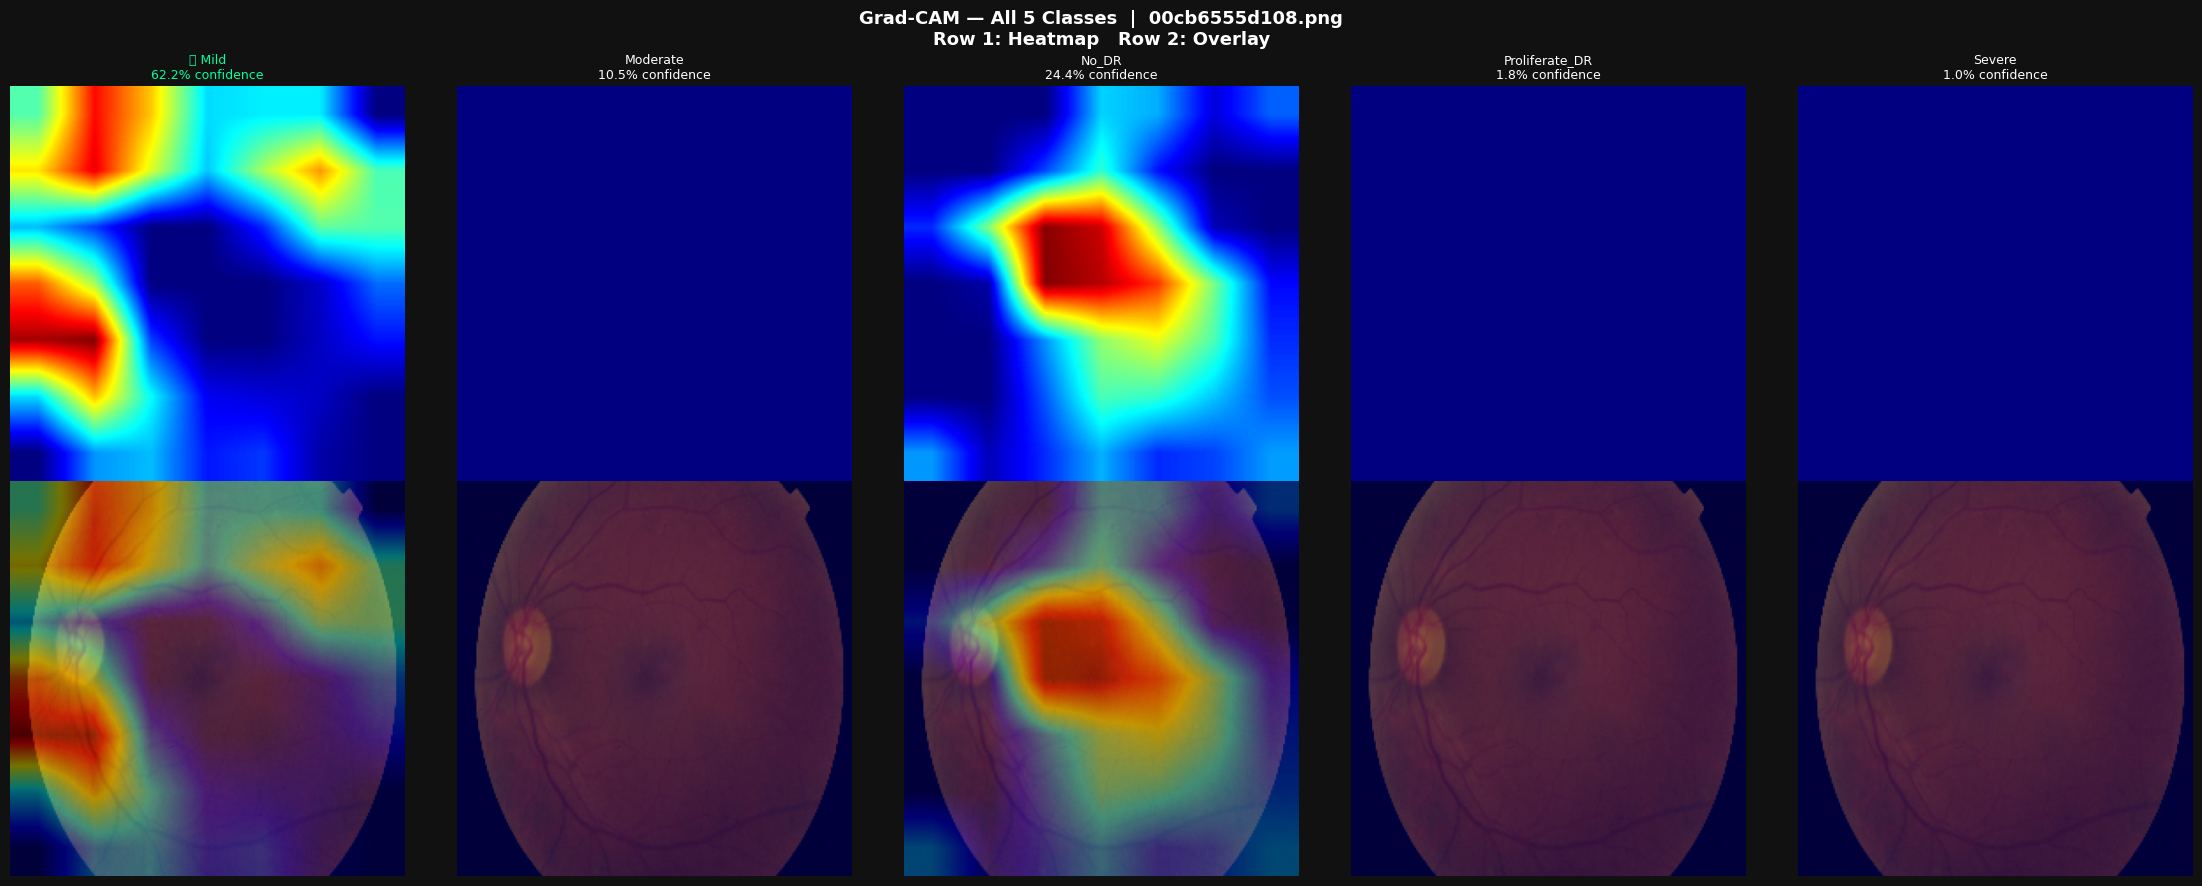

💾  Saved → gradcam_all_classes.png
compare_all_classes() defined ✅  (uncomment call above to run)


In [23]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 8 — COMPARE ALL 5 CLASSES ON ONE IMAGE (great for viva demo)        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def compare_all_classes(image_path, model, class_names,
                         alpha=0.45, save_path='gradcam_all_classes.png'):
    """
    Runs Grad-CAM for EVERY class on the same image.
    Top row = heatmaps, bottom row = overlays.
    The predicted class is highlighted with ⭐.
    """
    img_array, original_img = preprocess_image(image_path, IMG_SIZE)
    n = len(class_names)

    fig, axes = plt.subplots(2, n, figsize=(4.5 * n, 9))
    fig.patch.set_facecolor('#111')
    fig.suptitle(
        f'Grad-CAM — All 5 Classes  |  {os.path.basename(image_path)}\n'
        'Row 1: Heatmap   Row 2: Overlay',
        color='white', fontsize=13, fontweight='bold'
    )

    # Run once to get predicted class
    _, predicted_idx, _ = make_gradcam_heatmap(img_array, model)

    for ci in range(n):
        heatmap, _, pred_probs = make_gradcam_heatmap(
            img_array, model, pred_index=ci
        )
        superimposed, hm_rgb = overlay_heatmap(original_img, heatmap, alpha=alpha)

        star = '⭐ ' if ci == predicted_idx else ''
        title_color = '#00ff9f' if ci == predicted_idx else 'white'
        title_txt = (f'{star}{class_names[ci]}\n'
                     f'{pred_probs[ci]*100:.1f}% confidence')

        axes[0, ci].imshow(hm_rgb)
        axes[0, ci].set_title(title_txt, color=title_color, fontsize=9)
        axes[0, ci].axis('off')

        axes[1, ci].imshow(superimposed)
        axes[1, ci].axis('off')

    plt.tight_layout()
    plt.savefig(save_path, dpi=130, bbox_inches='tight', facecolor='#111')
    plt.show()
    print(f'💾  Saved → {save_path}')


# ── Uncomment to run ─────────────────────────────────────────────────────────
compare_all_classes(
     image_path = TEST_IMAGE_PATH,
     model      = model,
     class_names= CLASS_NAMES,
     save_path  = 'gradcam_all_classes.png'
)

print('compare_all_classes() defined ✅  (uncomment call above to run)')

📁  Output folder: gradcam_per_class

  Processing : 0024cdab0c1e.png
  ✅ Preprocessed  shape: (1, 224, 224, 3)
✅ Backbone       : efficientnetb0
✅ Last Conv2D    : top_conv
  ✅ Heatmap generated  shape: (7, 7)
  🎯 Predicted : Mild  (67.7%)
  ✅ Overlay created


C:\Users\User\AppData\Local\Temp\ipykernel_12896\1692087799.py:85: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_12896\1692087799.py:86: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='#0d0d0d')


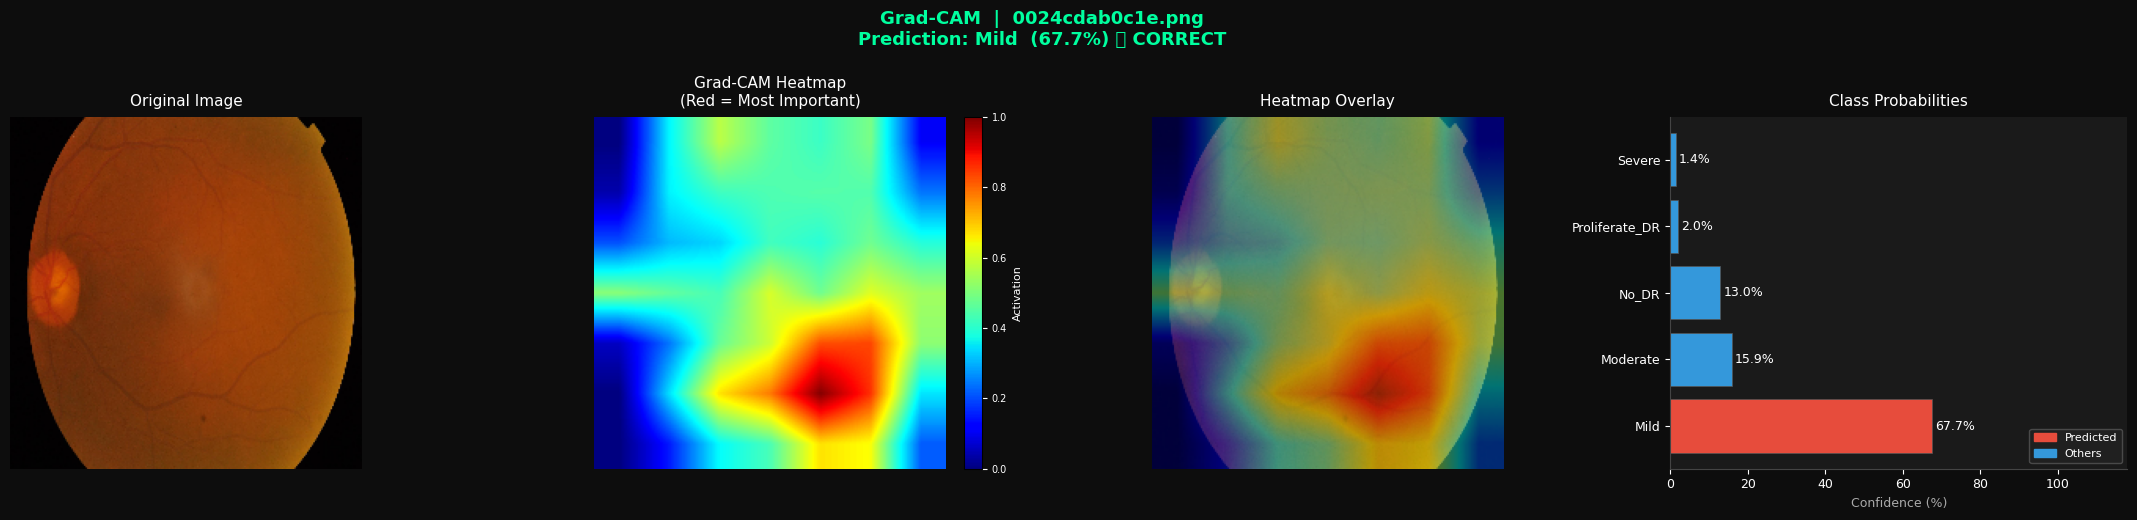

💾  Saved → gradcam_per_class\Mild_gradcam.png

  Class probabilities:
    Mild               ████████████████████            67.7% ←
    Moderate           ████                            15.9%
    No_DR              ███                             13.0%
    Proliferate_DR                                      2.0%
    Severe                                              1.4%

  Processing : 000c1434d8d7.png
  ✅ Preprocessed  shape: (1, 224, 224, 3)
✅ Backbone       : efficientnetb0
✅ Last Conv2D    : top_conv
  ✅ Heatmap generated  shape: (7, 7)
  🎯 Predicted : Moderate  (65.1%)
  ✅ Overlay created


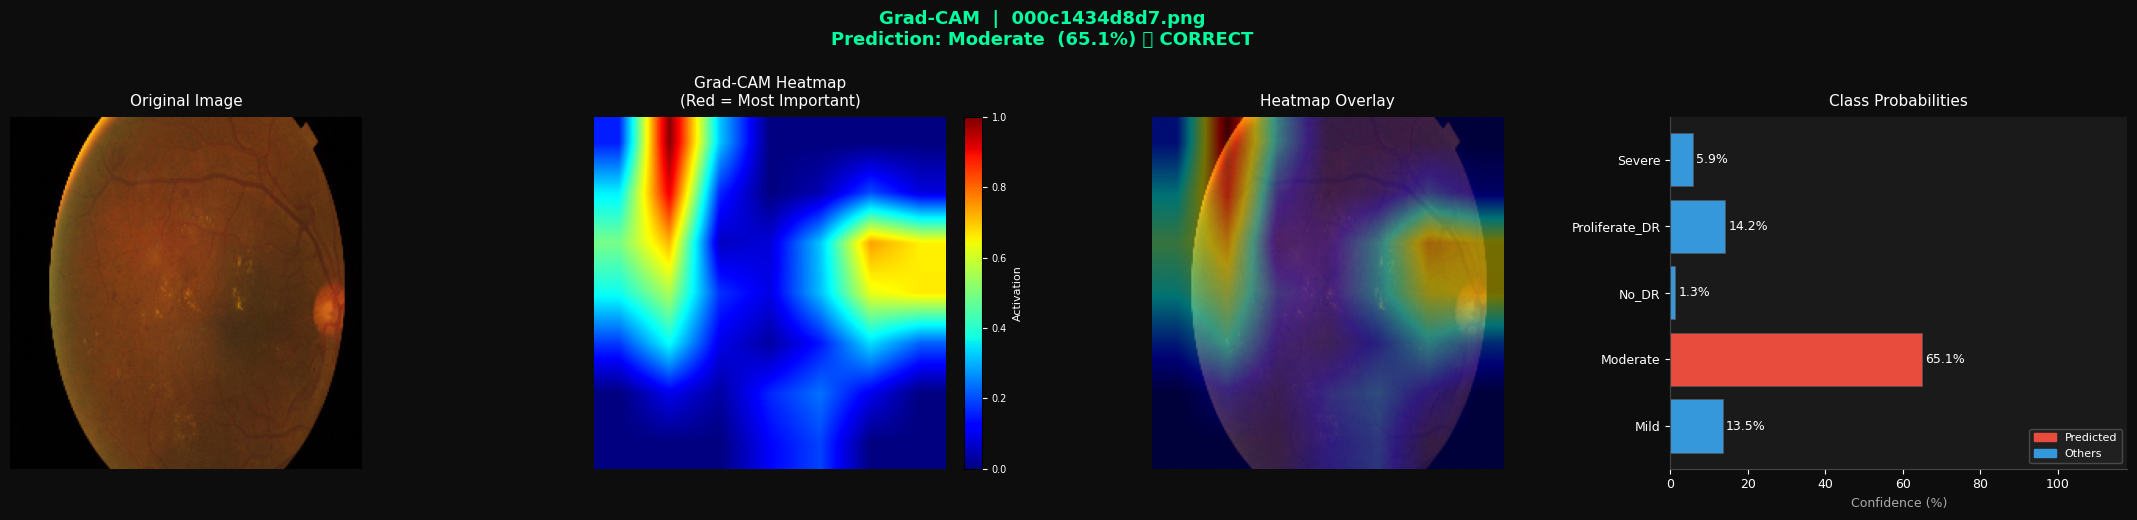

💾  Saved → gradcam_per_class\Moderate_gradcam.png

  Class probabilities:
    Mild               ████                            13.5%
    Moderate           ███████████████████             65.1% ←
    No_DR                                               1.3%
    Proliferate_DR     ████                            14.2%
    Severe             █                                5.9%

  Processing : 002c21358ce6.png
  ✅ Preprocessed  shape: (1, 224, 224, 3)
✅ Backbone       : efficientnetb0
✅ Last Conv2D    : top_conv
  ✅ Heatmap generated  shape: (7, 7)
  🎯 Predicted : No_DR  (95.2%)
  ✅ Overlay created


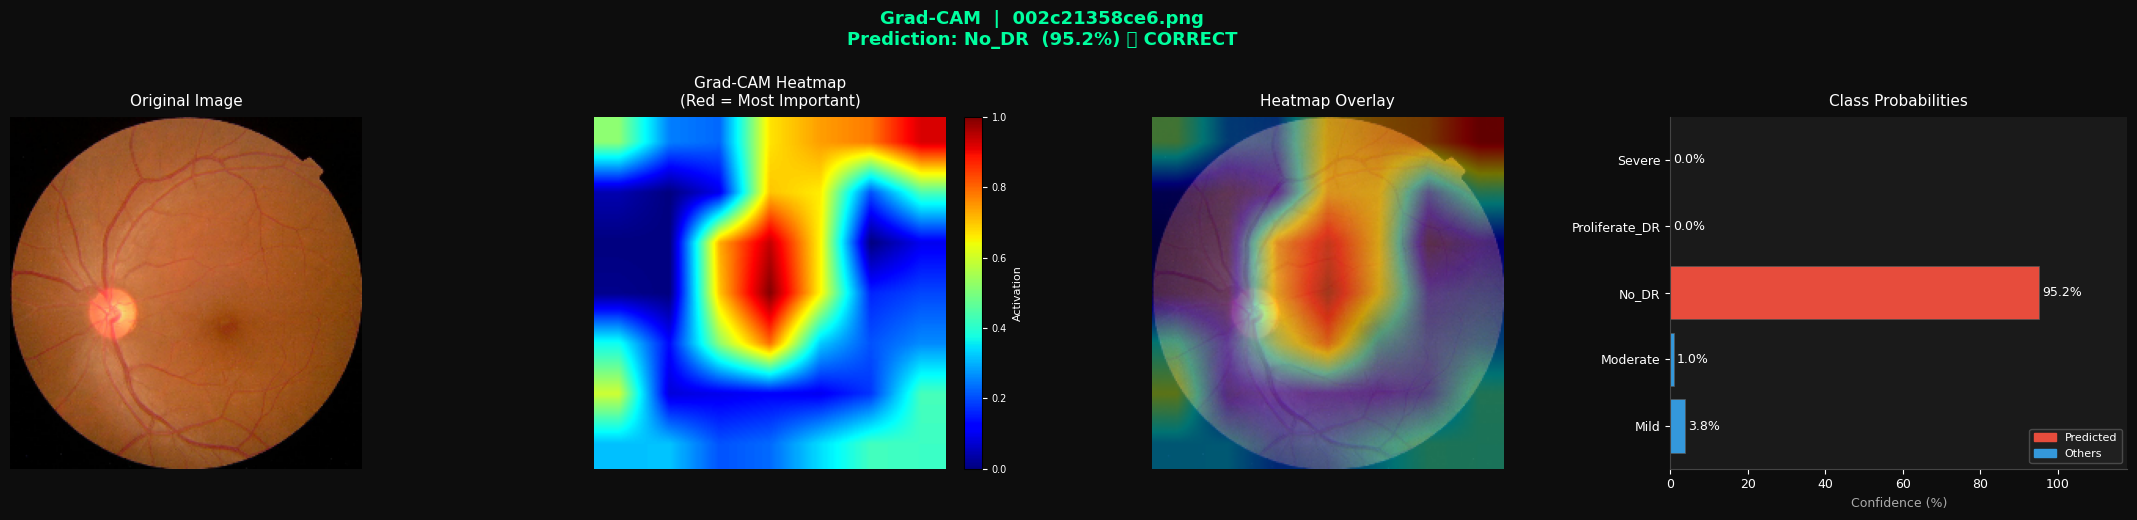

💾  Saved → gradcam_per_class\No_DR_gradcam.png

  Class probabilities:
    Mild               █                                3.8%
    Moderate                                            1.0%
    No_DR              ████████████████████████████    95.2% ←
    Proliferate_DR                                      0.0%
    Severe                                              0.0%

  Processing : 001639a390f0.png
  ✅ Preprocessed  shape: (1, 224, 224, 3)
✅ Backbone       : efficientnetb0
✅ Last Conv2D    : top_conv
  ✅ Heatmap generated  shape: (7, 7)
  🎯 Predicted : Moderate  (46.3%)
  ✅ Overlay created


C:\Users\User\AppData\Local\Temp\ipykernel_12896\1692087799.py:85: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_12896\1692087799.py:86: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


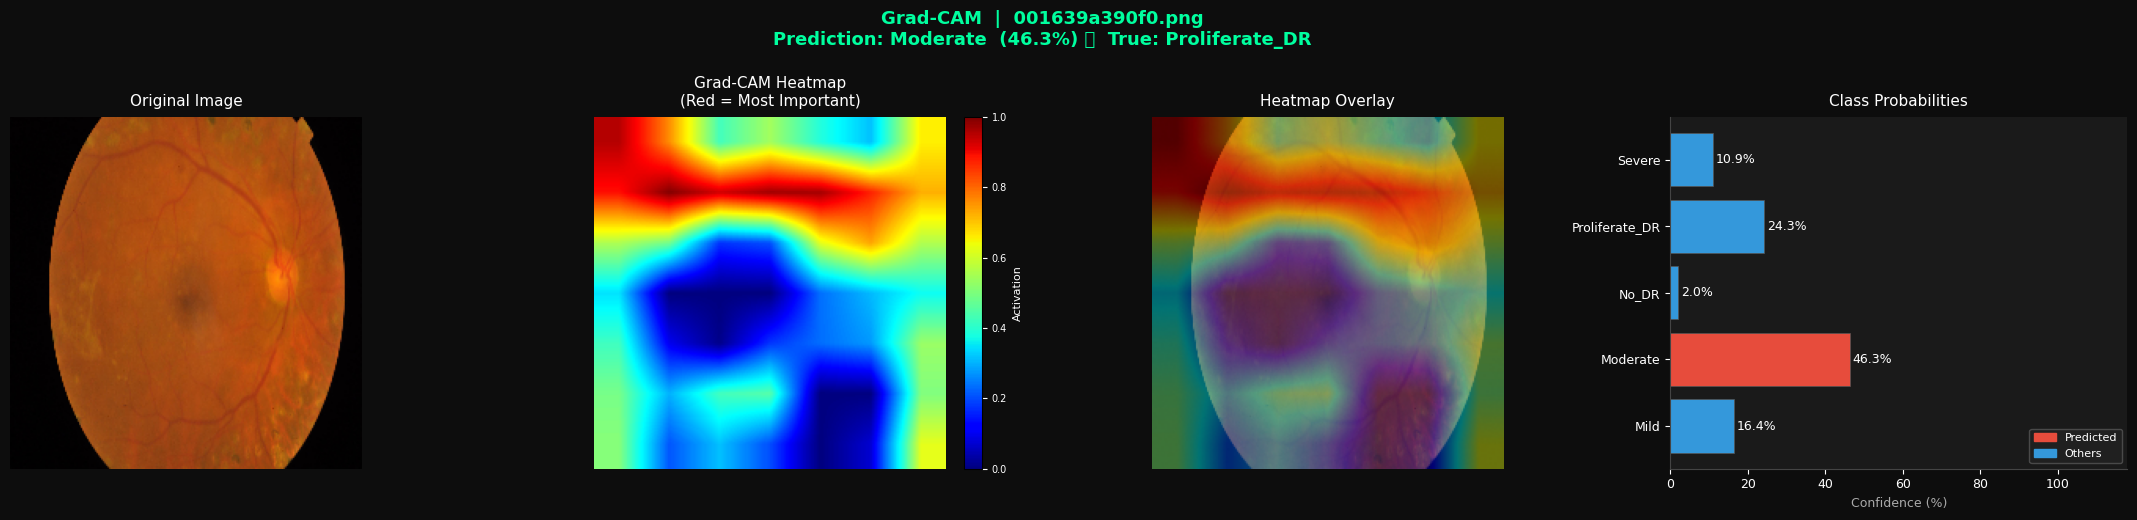

💾  Saved → gradcam_per_class\Proliferate_DR_gradcam.png

  Class probabilities:
    Mild               ████                            16.4%
    Moderate           █████████████                   46.3% ←
    No_DR                                               2.0%
    Proliferate_DR     ███████                         24.3%
    Severe             ███                             10.9%

  Processing : 0104b032c141.png
  ✅ Preprocessed  shape: (1, 224, 224, 3)
✅ Backbone       : efficientnetb0
✅ Last Conv2D    : top_conv
  ✅ Heatmap generated  shape: (7, 7)
  🎯 Predicted : Severe  (65.2%)
  ✅ Overlay created


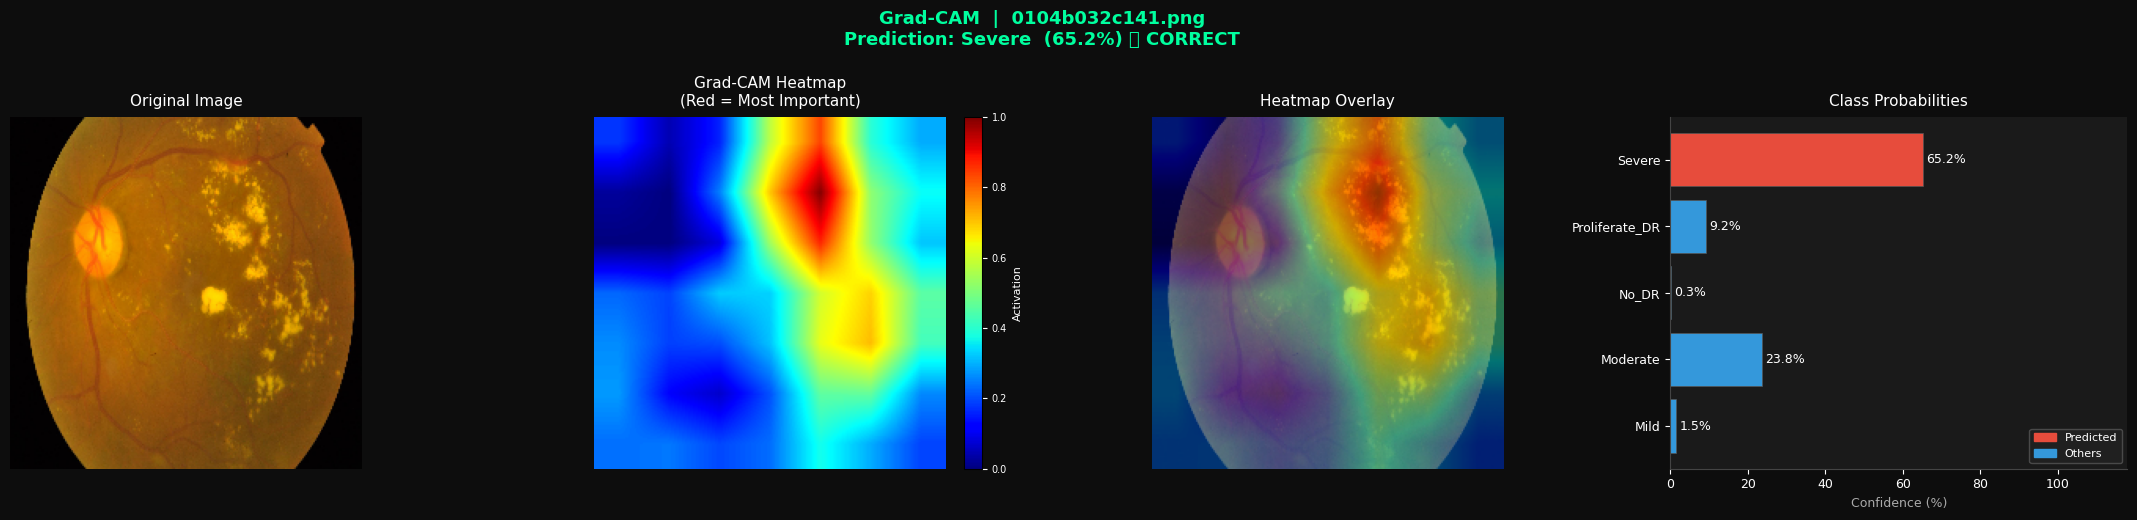

💾  Saved → gradcam_per_class\Severe_gradcam.png

  Class probabilities:
    Mild                                                1.5%
    Moderate           ███████                         23.8%
    No_DR                                               0.3%
    Proliferate_DR     ██                               9.2%
    Severe             ███████████████████             65.2% ←
run_one_per_class() defined ✅  (uncomment call above to run)


In [24]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 9 — AUTO SAMPLE: ONE IMAGE PER SEVERITY CLASS                       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def run_one_per_class(base_dir, model, class_names,
                      alpha=0.45, save_dir='gradcam_per_class'):
    """
    Picks the first image from each class sub-folder and generates
    a Grad-CAM visualisation for it.

    Folder structure expected:
        base_dir/
          Mild/          *.png
          Moderate/      *.png
          No_DR/         *.png
          Proliferate_DR/*.png
          Severe/        *.png
    """
    os.makedirs(save_dir, exist_ok=True)
    print(f'📁  Output folder: {save_dir}')

    for ci, class_name in enumerate(class_names):
        class_dir = os.path.join(base_dir, class_name)
        if not os.path.isdir(class_dir):
            print(f'⚠️   Not found: {class_dir}')
            continue

        imgs = sorted([
            f for f in os.listdir(class_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])
        if not imgs:
            print(f'⚠️   No images in {class_dir}')
            continue

        img_path  = os.path.join(class_dir, imgs[0])
        save_path = os.path.join(save_dir, f'{class_name}_gradcam.png')

        run_gradcam(
            image_path  = img_path,
            model       = model,
            class_names = class_names,
            true_label  = ci,
            alpha       = alpha,
            save_path   = save_path
        )


# ── Uncomment to run ─────────────────────────────────────────────────────────
run_one_per_class(
     base_dir    = DATASET_DIR,
     model       = model,
     class_names = CLASS_NAMES,
     save_dir    = 'gradcam_per_class'
 )

print('run_one_per_class() defined ✅  (uncomment call above to run)')

In [26]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — BATCH PROCESSING (multiple images at once)                     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def run_gradcam_batch(image_paths, model, class_names,
                      true_labels=None, alpha=0.45,
                      save_dir='gradcam_batch_outputs'):
    """
    Runs Grad-CAM on a list of images and saves results silently
    (no plt.show() popups during batch; saves to files instead).

    Returns list of result dicts.
    """
    os.makedirs(save_dir, exist_ok=True)
    results = []
    n = len(image_paths)

    for i, img_path in enumerate(image_paths):
        true_label = true_labels[i] if true_labels else None
        try:
            img_array, original_img = preprocess_image(img_path, IMG_SIZE)
            heatmap, pred_index, pred_probs = make_gradcam_heatmap(
                img_array, model
            )
            superimposed, hm_rgb = overlay_heatmap(
                original_img, heatmap, alpha=alpha
            )

            # Save a 3-panel figure without showing it
            fig, ax = plt.subplots(1, 3, figsize=(15, 5))
            fig.patch.set_facecolor('#0d0d0d')
            for axis, img, ttl in zip(
                ax,
                [original_img, hm_rgb, superimposed],
                ['Original', 'Grad-CAM', 'Overlay']
            ):
                axis.imshow(img)
                axis.set_title(ttl, color='white')
                axis.axis('off')
                axis.set_facecolor('#0d0d0d')

            pred_class = class_names[pred_index]
            conf       = pred_probs[pred_index] * 100
            correct_s  = ''
            if true_label is not None:
                correct_s = (' ✅' if true_label == pred_index
                             else f' ❌ True:{class_names[true_label]}')
            fig.suptitle(f'Pred: {pred_class} ({conf:.1f}%){correct_s}',
                         color='#00ff9f', fontsize=11)
            plt.tight_layout()

            base      = os.path.splitext(os.path.basename(img_path))[0]
            save_path = os.path.join(save_dir, f'{base}_gradcam.png')
            plt.savefig(save_path, dpi=120, bbox_inches='tight',
                        facecolor='#0d0d0d')
            plt.close()

            results.append({
                'image_path': img_path,
                'pred_class': pred_class,
                'confidence': conf,
                'true_label': true_label,
                'correct'   : (true_label == pred_index) if true_label is not None else None,
                'saved_to'  : save_path
            })
            print(f'[{i+1:3d}/{n}] {os.path.basename(img_path):<35} '
                  f'→ {pred_class:<18} ({conf:.1f}%){correct_s}')

        except Exception as exc:
            print(f'[{i+1:3d}/{n}] ❌  {img_path}: {exc}')
            results.append({'image_path': img_path, 'error': str(exc)})

    # Summary
    print(f'\n{"="*65}')
    print(f'  Batch complete  ✅  — {n} images processed')
    if true_labels:
        ok = sum(r.get('correct', False) for r in results)
        print(f'  Accuracy : {ok}/{n}  ({ok/n*100:.1f}%)')
    print(f'  Saved to : {save_dir}/')
    print(f'{"="*65}')
    return results


# ── Example usage (uncomment and edit paths) ──────────────────────────────────
# test_images = [
#     'F:/DR_Project/data/train_images/Mild/00cb6555d108.png',
#     'F:/DR_Project/data/train_images/Moderate/0024cdab0c1e.png',
#     'F:/DR_Project/data/train_images/No_DR/002c21358ce6.png',
#     'F:/DR_Project/data/train_images/Severe/004e48aec2c0.png',
#     'F:/DR_Project/data/train_images/Proliferate_DR/005b95c28852.png',
# ]
#batch_results = run_gradcam_batch(
 #    image_paths = test_images,
  #   model       = model,
   #  class_names = CLASS_NAMES,
    # true_labels = [0, 1, 2, 4, 3],
    # save_dir    = 'gradcam_batch_outputs'
#)

print('run_gradcam_batch() defined ✅  (uncomment example above to run)')

run_gradcam_batch() defined ✅  (uncomment example above to run)


---

## 🎓 Viva Quick-Reference

| Question | Answer |
|---|---|
| What does red mean in the heatmap? | Highest activation — regions that contributed most to the predicted class. |
| Why last Conv2D layer? | It contains the richest high-level semantic features (lesion shapes, textures). Earlier layers only detect edges. |
| Why ReLU on the heatmap? | We only care about regions that *increase* the class score. Negative values suppress the class — not relevant for explaining the positive prediction. |
| Does Grad-CAM change the model? | No. It is a **post-hoc** method — reads from a frozen trained model. |
| Why not saliency maps instead? | Saliency maps compute gradients w.r.t. *input pixels* → noisy. Grad-CAM uses gradients w.r.t. *feature maps* → smoother, clinically interpretable. |
| Why is Val Accuracy > Train Accuracy early on? | Heavy augmentation + dropout on train set. The model trains harder than it tests. |

---

## 📋 Function Summary

| Function | What it does |
|---|---|
| `find_last_conv_layer(model)` | Auto-detects last Conv2D inside EfficientNetB0 — **no hardcoded names** |
| `preprocess_image(path, size)` | BGR→RGB, resize, float32, batch dim |
| `make_gradcam_heatmap(img, model)` | Core Grad-CAM via GradientTape |
| `overlay_heatmap(img, heatmap)` | Resize & blend heatmap on original |
| `display_gradcam(...)` | 4-panel dark-theme figure + save |
| `run_gradcam(path, model, ...)` | **Master function** — one image, full pipeline |
| `compare_all_classes(path, ...)` | Grad-CAM for all 5 classes side-by-side |
| `run_one_per_class(base_dir, ...)` | Auto-samples 1 image per severity class |
| `run_gradcam_batch(paths, ...)` | Batch processing, saves silently |

---